<a href="https://colab.research.google.com/github/Bibhuti-MLAI/Time-Series-Forcasting/blob/main/Revenue_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
#required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
data_path = r"/content/drive/MyDrive/Alma Better/Revenue Forcasting/bfsi_revenue_forecasting_project/data/BFSI_Revenue_Forecasting_Dataset_fixed.xlsx"
RANDOM_STATE = 42

In [89]:
customer = pd.read_excel(data_path, sheet_name="Customer_Master")

In [90]:
customer.head()

,customer_id,customer_name,segment,industry,onboarding_date,credit_limit,risk_grade,geography
0,CUST00056,Client Enterprises 56,Medium,Pharma,15/11/18,10926167.91,C,NaN
1,CUST00052,Client Enterprises 52,Micro,Logistics,07/24/2018,25541292.36,B,Telangana
2,CUST00002,Client Enterprises 2,MSME,Logistics,17-10-2021,29729379.37,A,Maharashtra
3,CUST00089,Client Enterprises 89,SME,IT Services,04/18/2022,14092573.62,A,Delhi NCR
4,CUST00048,Client Enterprises 48,SME,Textiles,03/09/18,29928698.10,A+,Karnataka


In [91]:
invoice = pd.read_excel(data_path, sheet_name="Invoice_Data")
payment = pd.read_excel(data_path, sheet_name="Payment_Data")
repayment =pd.read_excel(data_path, sheet_name="Repayment_Data")

In [92]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      113 non-null    object 
 1   customer_name    113 non-null    object 
 2   segment          113 non-null    object 
 3   industry         113 non-null    object 
 4   onboarding_date  113 non-null    object 
 5   credit_limit     104 non-null    float64
 6   risk_grade       98 non-null     object 
 7   geography        107 non-null    object 
dtypes: float64(1), object(7)
memory usage: 7.2+ KB


In [93]:
customer.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_limit,104.0,2.464384e+07,1.384461e+07,583718.27,12734032.6,2.558577e+07,35548554.17,49400676.43


In [94]:
customer['customer_id'].count()

np.int64(113)

Clean Customer_master

In [95]:
customer['customer_id']= customer['customer_id'].astype(str).str.strip().str.upper()

In [96]:
customer

,customer_id,customer_name,segment,industry,onboarding_date,credit_limit,risk_grade,geography
0,CUST00056,Client Enterprises 56,Medium,Pharma,15/11/18,10926167.91,C,NaN
1,CUST00052,Client Enterprises 52,Micro,Logistics,07/24/2018,25541292.36,B,Telangana
2,CUST00002,Client Enterprises 2,MSME,Logistics,17-10-2021,29729379.37,A,Maharashtra
3,CUST00089,Client Enterprises 89,SME,IT Services,04/18/2022,14092573.62,A,Delhi NCR
4,CUST00048,Client Enterprises 48,SME,Textiles,03/09/18,29928698.10,A+,Karnataka
...,...,...,...,...,...,...,...,...
108,CUST00029,Client Enterprises 29,MSME,IT Services,20/09/18,8673784.47,A+,TN
109,CUST00096,Client Enterprises 96,Large,IT Services,13-07-2019,19748431.56,NaN,West Bengal
110,CUST00016,Client Enterprises 16,MSME,IT Services,12-Mar-2019,44291816.12,NaN,MH
111,CUST00091,Client Enterprises 91,Small,Auto Ancillary,11/05/2018,35467747.51,A,West Bengal


In [97]:
digits = customer['customer_id'].str.extract(r"CUST0*(\d+)")[0]
customer["customer_id"] = "CUST" + digits.str.zfill(5)
customer["customer_id"].head()

,customer_id
0,CUST00056
1,CUST00052
2,CUST00002
3,CUST00089
4,CUST00048


In [98]:
digits

,0
0,56
1,52
2,2
3,89
4,48
...,...
108,29
109,96
110,16
111,91


In [99]:
customer["customer_name"] = customer["customer_name"].astype(str).str.strip()

In [100]:
customer["onboarding_date"] =pd.to_datetime(customer["onboarding_date"],dayfirst=True,errors="coerce")
customer[["customer_id","customer_name","onboarding_date"]].head()

/tmp/ipykernel_653/2456310456.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer["onboarding_date"] =pd.to_datetime(customer["onboarding_date"],dayfirst=True,errors="coerce")


,customer_id,customer_name,onboarding_date
0,CUST00056,Client Enterprises 56,2018-11-15
1,CUST00052,Client Enterprises 52,2018-07-24
2,CUST00002,Client Enterprises 2,2021-10-17
3,CUST00089,Client Enterprises 89,2022-04-18
4,CUST00048,Client Enterprises 48,2018-09-03


In [101]:
from numpy._core.defchararray import title
#standardise free text categories
customer["industry"] = customer["industry"].astype(str).str.strip().str.title()
customer["geography"] = customer["geography"].astype(str).str.strip().str.title()
customer["geography"] = customer["geography"].replace({"Mh":"Maharastra","Tn":"Tamil nadu"})
customer.loc[customer["geography"].isin(["Nan","None"]),"geography"] = np.nan

customer["segment"] = customer["segment"].astype(str).str.strip().str.title()
customer["segment"] = customer["segment"].replace({"Sme":"SME","Msme":"MSME"})
customer[["segment","industry","geography"]].head()

,segment,industry,geography
0,Medium,Pharma,NaN
1,Micro,Logistics,Telangana
2,MSME,Logistics,Maharashtra
3,SME,It Services,Delhi Ncr
4,SME,Textiles,Karnataka


In [102]:
before  = len(customer)
customer = customer.sort_values("customer_id").drop_duplicates(subset="customer_id",keep = "first")
print(f"Customer_master:{before} -> {len(customer)} rows after removing duplicates")

Customer_master:113 -> 110 rows after removing duplicates


In [103]:
#Missing Values
print("Missing Values : ")
print(customer[["geography","credit_limit","risk_grade"]].isna().sum())

Missing Values : 
geography        6
credit_limit     9
risk_grade      15
dtype: int64


In [104]:
customer["geography"] = customer['geography'].fillna("Unknown")
customer["credit_limit"] = customer.groupby("segment")["credit_limit"].transform(lambda x: x.fillna(x.median()))
customer["credit_limit"] = customer["credit_limit"].fillna(customer["credit_limit"].median())
customer['risk_grade'] = customer["risk_grade"].fillna("Unrated")

print("Missing after")
print(customer[["geography","credit_limit","risk_grade"]].isna().sum())

Missing after
geography       0
credit_limit    0
risk_grade      0
dtype: int64


Cleaning Invoice data

In [105]:
invoice["customer_id"] = invoice["customer_id"].astype(str).str.strip().str.upper()
digits = invoice["customer_id"].str.extract(r"CUST0*(\D+)")[0]

invoice["invoice_date"] = pd.to_datetime(invoice["invoice_date"], dayfirst=True, errors = "coerce")
invoice["due_date"] = pd.to_datetime(invoice["due_date"],dayfirst=True,errors = "coerce")
invoice["invoice_status"] = invoice["invoice_status"].astype(str).str.strip().str.title()
invoice["discounting_flag"] = invoice["discounting_flag"].astype(str).str.strip().str.upper()
invoice.head()

/tmp/ipykernel_653/1418042568.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  invoice["invoice_date"] = pd.to_datetime(invoice["invoice_date"], dayfirst=True, errors = "coerce")


,invoice_id,customer_id,invoice_date,invoice_amount,due_date,invoice_status,discounting_flag
0,INV0001348,CUST00072,2023-09-25,60110.08,2023-10-25,Open,Y
1,INV0001541,CUST00083,2022-09-13,60974.11,NaT,Paid,Y
2,INV0001936,CUST00105,2022-03-02,74165.65,2022-04-16,Partially Paid,N
3,INV0000293,CUST00015,2022-08-20,97633.69,NaT,Paid,N
4,INV0000372,CUST00020,2023-05-15,104900.40,NaT,Overdue,Y


In [106]:
before = len(invoice)
invoice = invoice.drop_duplicates()
print(f"invoice_data:removed {before - len(invoice)} extract duplicate rows")

invoice_data:removed 5 extract duplicate rows


In [107]:
valid_customer_ids = set(customer["customer_id"])
is_orphan = ~invoice["customer_id"].isin(valid_customer_ids)
print(f"Invoice_data: {is_orphan.sum()} orphan invoices - excluding")
invoice = invoice[~is_orphan]

Invoice_data: 27 orphan invoices - excluding


In [108]:
is_orphan.count()

np.int64(2044)

In [109]:
n_negative = (invoice["invoice_amount"] < 0).sum()
print(f"Invoice_data : {n_negative} negative invoice amount rows - excluding")
invoice = invoice[invoice["invoice_amount"].isna() | (invoice["invoice_amount"] >=0)]

Invoice_data : 1 negative invoice amount rows - excluding


In [110]:
n_missing  = (invoice["invoice_amount"].isna().sum())
invoice = invoice.dropna(subset= ["invoice_amount"])
print(f"Invoice_data: Dropped {n_missing} rows with missing invoice_amount")

Invoice_data: Dropped 59 rows with missing invoice_amount


In [111]:
cap = invoice["invoice_amount"].quantile(0.995)
n_capped = (invoice["invoice_amount"] > cap).sum()
invoice["invoice_amount_capped"] = invoice["invoice_amount"].clip(upper=cap)
print(f"Invoice_data: capped {n_capped} outlier rows at rupees {cap :,.0f}")
invoice.shape

Invoice_data: capped 10 outlier rows at rupees 1,001,775


(1957, 8)

In [112]:
invoice.head()

,invoice_id,customer_id,invoice_date,invoice_amount,due_date,invoice_status,discounting_flag,invoice_amount_capped
0,INV0001348,CUST00072,2023-09-25,60110.08,2023-10-25,Open,Y,60110.08
1,INV0001541,CUST00083,2022-09-13,60974.11,NaT,Paid,Y,60974.11
2,INV0001936,CUST00105,2022-03-02,74165.65,2022-04-16,Partially Paid,N,74165.65
3,INV0000293,CUST00015,2022-08-20,97633.69,NaT,Paid,N,97633.69
4,INV0000372,CUST00020,2023-05-15,104900.40,NaT,Overdue,Y,104900.40


In [113]:
#Clean Payment data
payment["customer_id"] = payment["customer_id"].astype(str).str.strip().str.upper()
digits = payment["customer_id"].str.extract(r"CUST0*(\d+)")[0]
payment["customer_id"] = "CUST" +digits.str.zfill(5)

payment["payment_date"] = pd.to_datetime(payment["payment_date"], dayfirst=True, errors = "coerce")
payment["payment_mode"] = payment["payment_mode"].astype(str).str.strip().str.upper()
payment["payment_mode"] = payment["payment_mode"].replace({"WIRE TRANSFER" : "WIRE"})

before =len(payment)
payment = payment.drop_duplicates()
print(f"Payment_Data: removed {before - len(payment)} exact duplicate rows")

Payment_Data: removed 0 exact duplicate rows


/tmp/ipykernel_653/99731555.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  payment["payment_date"] = pd.to_datetime(payment["payment_date"], dayfirst=True, errors = "coerce")


In [114]:
# Orphan payments: invoice_id not present in the cleaned Invoice_Data
valid_invoice_ids = set(invoice["invoice_id"])
is_orphan = ~payment["invoice_id"].isin(valid_invoice_ids)
print(f"payment_data : {is_orphan.sum()} orphan paymnet - excluding")
payment = payment[~is_orphan]

payment_data : 17 orphan paymnet - excluding


In [115]:
n_missing_fee = payment["fee_charged"].isna().sum()
payment["fee_charged"] = payment["fee_charged"].fillna(0)
print(f"Payment_Data: {n_missing_fee} missing fee_charged -> filled with 0")
payment.shape

Payment_Data: 0 missing fee_charged -> filled with 0


(1374, 7)

In [116]:
#Clean Repayment Data
repayment["customer_id"] = repayment["customer_id"].astype(str).str.strip().str.upper()
digits = repayment['customer_id'].str.extract(r"CUST0(\d+)")[0]
repayment["customer_id"] = "CUST" + digits.str.zfill(5)

repayment["repayment_date"] = pd.to_datetime(repayment["repayment_date"],dayfirst = True,errors="coerce")
repayment["overdue_flag"] = repayment["overdue_flag"].astype(str).str.strip().str.upper()

before = len(repayment)
repayment= repayment = repayment.drop_duplicates()
print(f"Repayment_Data: removed {before - len(repayment)} exact duplicate rows")

Repayment_Data: removed 0 exact duplicate rows


In [117]:
invoice_customer_map =invoice.set_index("invoice_id")["customer_id"]
corrected = repayment["invoice_id"].map(invoice_customer_map)
n_mismatch = (corrected.notna() & (corrected != repayment["customer_id"])).sum()
print(f"Repayment_date: Correcting {n_mismatch} customer_id values that disagreed with the linked invoice")

repayment.loc[corrected.notna(), "customer_id"] = corrected[corrected.notna()]

n_unmatched = corrected.isna().sum()
repayment = repayment[corrected.notna()]
print(f"Repayment_date: dropped {n_unmatched} rows with no matching invoice_id")

Repayment_date: Correcting 0 customer_id values that disagreed with the linked invoice
Repayment_date: dropped 8 rows with no matching invoice_id


In [118]:
#missing discount_income
n_missing_income = repayment["discount_income"].isna().sum()
repayment = repayment.dropna(subset=["discount_income"])
print(f"Repayment_Date: dropped {n_missing_income} rows with missing discount income")

Repayment_Date: dropped 0 rows with missing discount income


In [119]:
bad_dpd = repayment["dpd"] == -9999
print(f"Repayment_date: fixing {bad_dpd.sum()} placeholder dpd values")

Repayment_date: fixing 0 placeholder dpd values


In [120]:
median_dpd = repayment.loc[repayment["dpd"] != -9999, "dpd"].median()
repayment.loc[bad_dpd & (repayment["overdue_flag"] == "N"), "dpd"] = 0
repayment.loc[bad_dpd & (repayment["overdue_flag"] != "N"), "dpd"] =median_dpd
repayment.shape

(854, 8)

In [121]:
#reconsilation
paid_per_invoice =payment.groupby("invoice_id")["payment_amount"].sum()
recon = invoice.set_index("invoice_id")[["invoice_amount"]].copy()
recon["total_paid"] = paid_per_invoice
recon["total_paid"] = recon["total_paid"].fillna(0)
recon["variance_pct"]  = ((recon["total_paid"] - recon["invoice_amount"]) / recon["invoice_amount"]).abs()

flagged = recon[recon["variance_pct"] > 0.02]
print(f"{len(flagged)} / {len(recon)} invoices have payment variance beyond 2% tolerance")

1696 / 1957 invoices have payment variance beyond 2% tolerance


Build the customer * month Panel

This is the grain the model actually needs : one row per customer per month

In [122]:
invoice["month"] = invoice["invoice_date"].dt.to_period("M").dt.to_timestamp()
payment["month"] = payment["payment_date"].dt.to_period("M").dt.to_timestamp()
repayment["month"] = repayment['repayment_date'].dt.to_period("M").dt.to_timestamp()

In [123]:
# Invoice activity per customer-month
invoice_monthly = invoice.groupby(["customer_id", "month"]).agg(
    invoice_count=("invoice_id", "count"),
    invoice_value=("invoice_amount_capped", "sum"),
    avg_invoice_size=("invoice_amount_capped", "mean"),
    pct_discounted=("discounting_flag", lambda x: (x == "Y").mean()),
).reset_index()
invoice_monthly.head()

,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted
0,CUST00001,2022-01-01,1,60479.25,60479.25,1.0
1,CUST00001,2022-09-01,2,449759.88,224879.94,1.0
2,CUST00001,2023-01-01,2,170657.00,85328.50,0.5
3,CUST00001,2023-06-01,1,27384.34,27384.34,0.0
4,CUST00001,2023-07-01,1,65050.82,65050.82,0.0


In [124]:
#fee income monthly
payment_monthly = payment.groupby(["customer_id","month"]).agg(
    fee_income = ("fee_charged","sum"),
    payment_count = ("payment_id" ,"count"),
).reset_index()

payment_monthly.head()

,customer_id,month,fee_income,payment_count
0,CUST00001,2022-02-01,143.81,1
1,CUST00001,2022-10-01,1307.74,1
2,CUST00001,2023-02-01,204.08,1
3,CUST00001,2023-07-01,223.64,1
4,CUST00001,2023-08-01,416.65,1


In [125]:
#discount_income + DPD behaviour per customer - month
repayment_monthly = repayment.groupby(["customer_id" , "month"]).agg(
    discount_income = ("discount_income" ,"sum"),
    avg_dpd = ("dpd" , "mean"),
    pct_overdue = ("overdue_flag" , lambda x: (x=="Y").mean()),
    repayment_count = ("repayment_id" , "count"),
).reset_index()

repayment_monthly.head()


,customer_id,month,discount_income,avg_dpd,pct_overdue,repayment_count
0,CUST00001,2022-02-01,2128.65,-5.0,0.0,1
1,CUST00001,2022-10-01,6381.81,-10.0,0.0,1
2,CUST00001,2024-09-01,1515.15,12.0,1.0,1
3,CUST00002,2024-12-01,1812.00,34.0,1.0,1
4,CUST00003,2022-08-01,3206.12,-5.0,0.0,1


In [126]:
#Build the full customer * month grid, so "no activity" becomes an explicit 0
#insted of missing row

all_months = pd.date_range (invoice["month"].min(),invoice["month"].max(),freq="MS")
panel = pd.MultiIndex.from_product(
    [customer["customer_id"].unique(), all_months], names=["customer_id","month"]
).to_frame(index=False)
panel.head()

,customer_id,month
0,CUST00001,2022-01-01
1,CUST00001,2022-02-01
2,CUST00001,2022-03-01
3,CUST00001,2022-04-01
4,CUST00001,2022-05-01


In [127]:
panel = panel.merge(invoice_monthly,on = ["customer_id" , "month"], how ="left")
panel = panel.merge(payment_monthly, on=["customer_id", "month"], how="left")
panel = panel.merge(repayment_monthly, on=["customer_id", "month"], how="left")

zero_fill_cols = ["invoice_count", "invoice_value", "fee_income", "payment_count",
                   "discount_income", "repayment_count", "pct_discounted", "pct_overdue"]
panel[zero_fill_cols] = panel[zero_fill_cols].fillna(0)
panel.head(10)

,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted,fee_income,payment_count,discount_income,avg_dpd,pct_overdue,repayment_count
0,CUST00001,2022-01-01,1.0,60479.25,60479.25,1.0,0.00,0.0,0.00,NaN,0.0,0.0
1,CUST00001,2022-02-01,0.0,0.00,NaN,0.0,143.81,1.0,2128.65,-5.0,0.0,1.0
2,CUST00001,2022-03-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
3,CUST00001,2022-04-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
4,CUST00001,2022-05-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
5,CUST00001,2022-06-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
6,CUST00001,2022-07-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
7,CUST00001,2022-08-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,0.0,0.0
8,CUST00001,2022-09-01,2.0,449759.88,224879.94,1.0,0.00,0.0,0.00,NaN,0.0,0.0
9,CUST00001,2022-10-01,0.0,0.00,NaN,0.0,1307.74,1.0,6381.81,-10.0,0.0,1.0


## 8. Build the targets: revenue, expense, profitability

**ASSUMPTION:** no expense table exists in the source data, so monthly
cost-to-serve is modeled as three components (replace with real cost-center
allocations when available):
- `funding_cost` — cost of capital on discounted invoices, ~8% p.a. prorated monthly
- `ops_cost` — a fixed cost per transaction handled
- `credit_cost` — a provisioning proxy scaled by overdue severity

In [128]:
panel["total_revenue"] = panel["discount_income"] + panel["fee_income"]

FUNDING_RATE_ANNUAL = 0.08
OPS_COST_PER_TXN = 150
CREDIT_COST_RATE = 0.015

panel["funding_cost"] = panel["invoice_value"] * (FUNDING_RATE_ANNUAL/12)
panel["ops_cost"] = (panel["invoice_count"] + panel["payment_count"]) * OPS_COST_PER_TXN
panel["credit_cost"] = panel["invoice_value"] * panel["pct_overdue"] * CREDIT_COST_RATE
panel["total_expense"] = panel["funding_cost"] + panel["ops_cost"] +panel["credit_cost"]

panel["profitability"] = panel["total_revenue"] - panel["total_expense"]
panel[["total_revenue" , "total_expense" , "profitability"]].describe()

,total_revenue,total_expense,profitability
count,3960.000000,3960.000000,3960.000000
mean,434.612093,644.245254,-209.633161
std,2128.444003,1214.218888,2336.286059
min,0.000000,0.000000,-18575.998767
25%,0.000000,0.000000,-604.214500
50%,0.000000,150.000000,0.000000
75%,180.505000,849.854850,0.000000
max,97656.070000,19243.968767,94586.543933


In [129]:
panel = panel.merge(
    customer[["customer_id" , "segment" , "industry" , "geography" , "risk_grade" ,
                              "credit_limit" , "onboarding_date"]],
on = "customer_id" , how="left"
)
print(f"panel: {panel.shape[0]} rows , {panel["customer_id"].nunique()} customer x {panel["month"].nunique()} months")
panel.head()

panel: 3960 rows , 110 customer x 36 months


,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted,fee_income,payment_count,discount_income,avg_dpd,...,ops_cost,credit_cost,total_expense,profitability,segment,industry,geography,risk_grade,credit_limit,onboarding_date
0,CUST00001,2022-01-01,1.0,60479.25,60479.25,1.0,0.00,0.0,0.00,NaN,...,150.0,0.0,553.195,-553.195,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
1,CUST00001,2022-02-01,0.0,0.00,NaN,0.0,143.81,1.0,2128.65,-5.0,...,150.0,0.0,150.000,2122.460,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
2,CUST00001,2022-03-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,...,0.0,0.0,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
3,CUST00001,2022-04-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,...,0.0,0.0,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
4,CUST00001,2022-05-01,0.0,0.00,NaN,0.0,0.00,0.0,0.00,NaN,...,0.0,0.0,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02


In [130]:
panel_full = panel.copy()

**EDA**

In [131]:
panel[["total_revenue", "total_expense", "profitability", "discount_income" , "fee_income"]].describe().round(0)

,total_revenue,total_expense,profitability,discount_income,fee_income
count,3960.0,3960.0,3960.0,3960.0,3960.0
mean,435.0,644.0,-210.0,210.0,225.0
std,2128.0,1214.0,2336.0,1850.0,645.0
min,0.0,0.0,-18576.0,0.0,0.0
25%,0.0,0.0,-604.0,0.0,0.0
50%,0.0,150.0,0.0,0.0,0.0
75%,181.0,850.0,0.0,0.0,108.0
max,97656.0,19244.0,94587.0,87102.0,10554.0


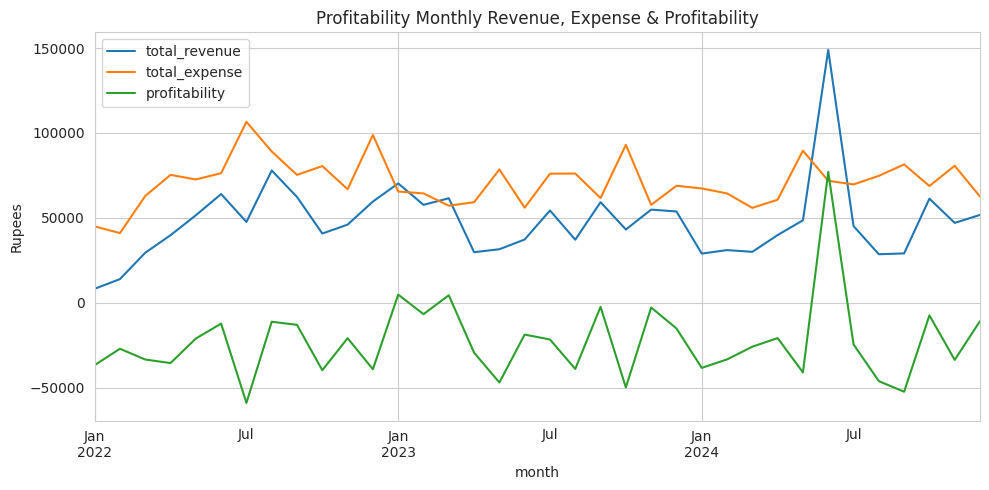

In [132]:
monthly_trend = panel.groupby("month")[["total_revenue","total_expense" , "profitability"]].sum()
plt.figure()
monthly_trend.plot(ax=plt.gca(),title = "Profitability Monthly Revenue, Expense & Profitability")
plt.ylabel("Rupees")
plt.tight_layout()
plt.show()

In [133]:
growth = monthly_trend["total_revenue"].pct_change().replace([np.inf, -np.inf],np.nan).mean()
print(f"Average month-on-month revenue growth: {growth:.1%}")

Average month-on-month revenue growth: 16.0%


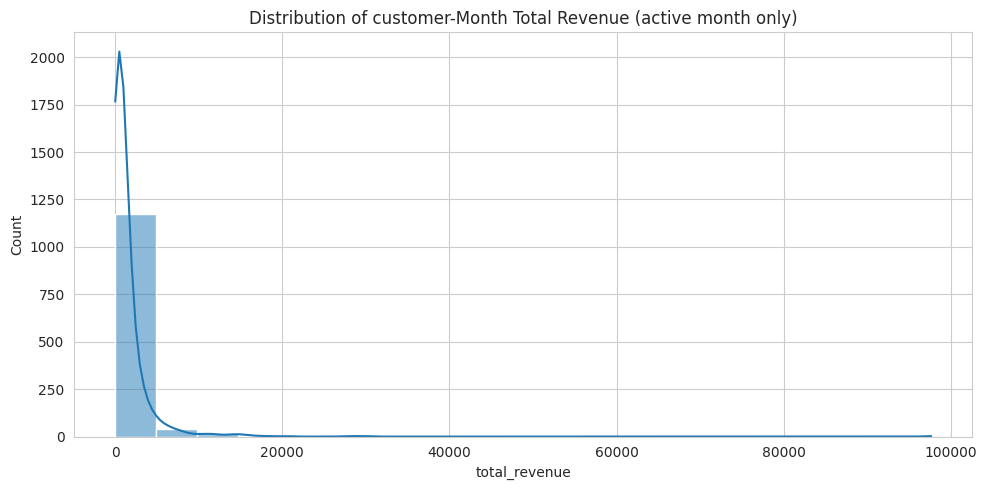

In [134]:
plt.figure()
sns.histplot(panel[panel["total_revenue"] > 0]["total_revenue"],bins=20,kde=True)
plt.title("Distribution of customer-Month Total Revenue (active month only)")
plt.tight_layout()
plt.show()

In [135]:
skew = panel[panel["total_revenue"] >0]["total_revenue"].skew()
print(f"Revenue distribution skew = {skew:.2f}")


Revenue distribution skew = 16.60


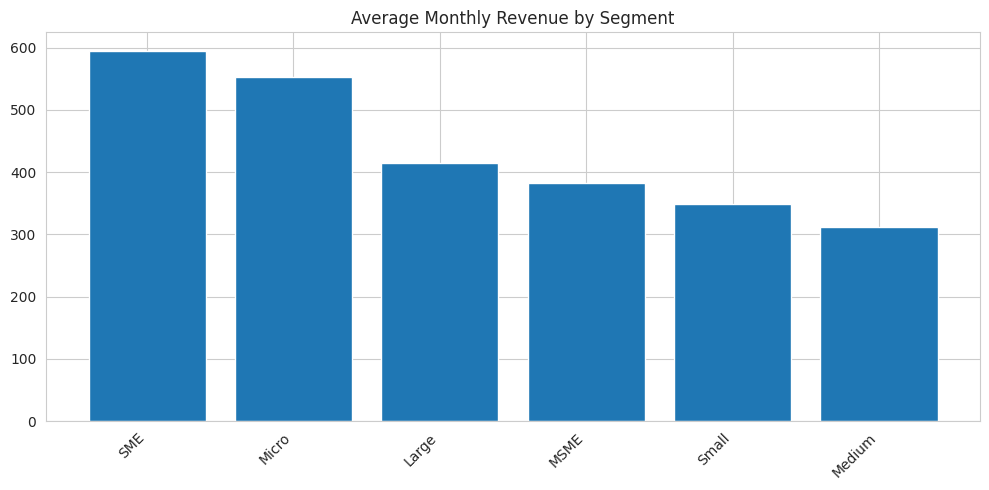

In [136]:
seg_revenue = panel.groupby("segment")["total_revenue"].mean().sort_values(ascending = False)
seg_labels = [str(v) for v in seg_revenue.index]

plt.figure()
plt.bar(seg_labels, seg_revenue.values)
plt.title("Average Monthly Revenue by Segment")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [137]:
#one-way ANOVA
groups = [g["total_revenue"].values for _, g in panel.groupby("segment") if len(g) > 5]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.2f}, p = {p_val:.4f}")
print("significant (p < 0.05) -> segment is worth keeping as a feature." if p_val < 0.05 else "Not Significant")

ANOVA: F = 1.87, p = 0.0970
Not Significant


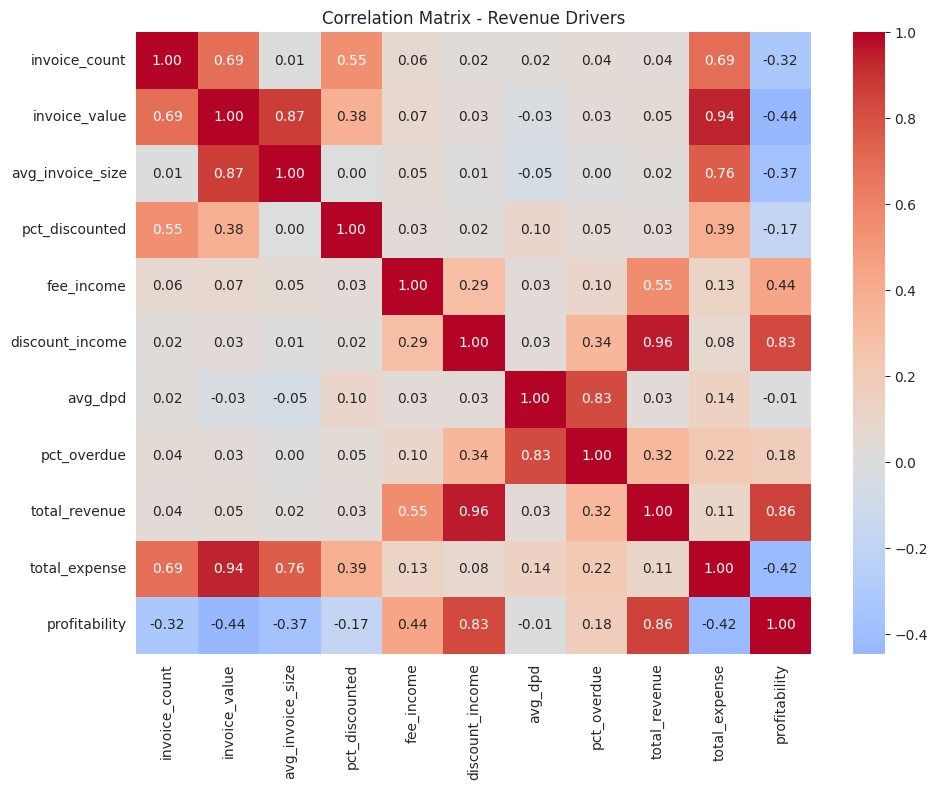

In [138]:
numeric_columns = ["invoice_count","invoice_value","avg_invoice_size","pct_discounted",
                   "fee_income","discount_income", "avg_dpd","pct_overdue",
                   "total_revenue","total_expense","profitability"]
corr = panel[numeric_columns].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True, fmt= ".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Revenue Drivers")
plt.tight_layout()
plt.show()

Feature Engineering

In [139]:
panel = panel.sort_values(["customer_id", "month"])
grouped = panel.groupby("customer_id")

# Fill "no activity" gaps in average-type columns by carrying the last known
# value forward within each customer, then 0 if there's no prior value at all
panel["avg_invoice_size"] = grouped["avg_invoice_size"].transform(lambda x: x.ffill().fillna(0))
panel["avg_dpd"] = grouped["avg_dpd"].transform(lambda x: x.ffill().fillna(0))
grouped = panel.groupby("customer_id")  # re-group after the update above

In [140]:
# Lag features: previous months' actuals as predictors
panel["revenue_lag_1"] = grouped["total_revenue"].shift(1)
panel["revenue_lag_2"] = grouped["total_revenue"].shift(2)
panel["revenue_lag_3"] = grouped["total_revenue"].shift(3)

panel["expense_lag_1"] = grouped["total_expense"].shift(1)
panel["expense_lag_2"] = grouped["total_expense"].shift(2)
panel["expense_lag_3"] = grouped["total_expense"].shift(3)

panel["invoice_count_lag_1"] = grouped["invoice_count"].shift(1)
panel["invoice_count_lag_2"] = grouped["invoice_count"].shift(2)
panel["invoice_count_lag_3"] = grouped["invoice_count"].shift(3)

panel[["customer_id", "month", "total_revenue", "revenue_lag_1", "revenue_lag_2"]].head(8)

,customer_id,month,total_revenue,revenue_lag_1,revenue_lag_2
0,CUST00001,2022-01-01,0.00,NaN,NaN
1,CUST00001,2022-02-01,2272.46,0.00,NaN
2,CUST00001,2022-03-01,0.00,2272.46,0.00
3,CUST00001,2022-04-01,0.00,0.00,2272.46
4,CUST00001,2022-05-01,0.00,0.00,0.00
5,CUST00001,2022-06-01,0.00,0.00,0.00
6,CUST00001,2022-07-01,0.00,0.00,0.00
7,CUST00001,2022-08-01,0.00,0.00,0.00


In [141]:
# Rolling trend features (trailing 3M / 6M), shifted by 1 month first
panel["revenue_roll3_mean"] = grouped["total_revenue"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
panel["revenue_roll6_mean"] = grouped["total_revenue"].transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
panel["revenue_roll3_std"] = grouped["total_revenue"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
panel["revenue_roll3_std"] = panel["revenue_roll3_std"].fillna(0)

In [142]:
# Growth rate features
panel["revenue_mom_growth"] = grouped["total_revenue"].transform(lambda x: x.shift(1).pct_change())
panel["invoice_count_mom_growth"] = grouped["invoice_count"].transform(lambda x: x.shift(1).pct_change())
panel = panel.replace([np.inf, -np.inf], np.nan)
panel["revenue_mom_growth"] = panel["revenue_mom_growth"].fillna(0)
panel["invoice_count_mom_growth"] = panel["invoice_count_mom_growth"].fillna(0)

In [143]:
# Behavioral / risk trend
panel["dpd_trend_3m"] = grouped["avg_dpd"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
panel["overdue_rate_lag_1"] = grouped["pct_overdue"].shift(1)

In [144]:
# Tenure and credit utilization
panel["tenure_months"] = ((panel["month"] - panel["onboarding_date"]).dt.days / 30.44).clip(lower=0)
panel["credit_utilization"] = (panel["invoice_value"] / panel["credit_limit"].replace(0, np.nan)).clip(upper=2)
panel["credit_utilization"] = panel["credit_utilization"].fillna(panel["credit_utilization"].median())

In [145]:
# Seasonality features
panel["calendar_month"] = panel["month"].dt.month
panel["quarter"] = panel["month"].dt.quarter
panel["is_fiscal_year_end"] = (panel["calendar_month"] == 3).astype(int)  # March = Indian FY-end

In [146]:
# Encode categoricals — pd.factorize is a simple built-in alternative to
# sklearn's LabelEncoder, no extra object to keep track of
panel["segment_enc"] = pd.factorize(panel["segment"])[0]
panel["industry_enc"] = pd.factorize(panel["industry"])[0]
panel["geography_enc"] = pd.factorize(panel["geography"])[0]
panel["risk_grade_enc"] = pd.factorize(panel["risk_grade"])[0]

In [147]:
# Drop rows with insufficient history for lag features (a brand-new
# customer's first 1-3 months) — a genuine cold-start limitation
before = len(panel)
panel = panel.dropna(subset=["revenue_lag_1", "revenue_roll3_mean"])
print(f"Dropped {before - len(panel)} cold-start rows with insufficient history")
panel.shape

Dropped 110 cold-start rows with insufficient history


(3850, 49)

## 11. Train / test split — time-based
The last 3 months become the test set for every customer. Never a random
split for a forecasting problem — that would leak future months into
training via the lag/rolling features.

In [148]:
feature_cols = [
    "invoice_count", "invoice_value", "avg_invoice_size", "pct_discounted",
    "payment_count", "repayment_count", "avg_dpd", "pct_overdue",
    "revenue_lag_1", "revenue_lag_2", "revenue_lag_3",
    "expense_lag_1", "expense_lag_2", "expense_lag_3",
    "invoice_count_lag_1", "invoice_count_lag_2", "invoice_count_lag_3",
    "revenue_roll3_mean", "revenue_roll6_mean", "revenue_roll3_std",
    "revenue_mom_growth", "invoice_count_mom_growth",
    "dpd_trend_3m", "overdue_rate_lag_1",
    "tenure_months", "credit_utilization",
    "calendar_month", "quarter", "is_fiscal_year_end",
    "segment_enc", "industry_enc", "geography_enc", "risk_grade_enc",
]

cutoff = panel["month"].max() - pd.DateOffset(months=3)
train = panel[panel["month"] <= cutoff]
test = panel[panel["month"] > cutoff]

print(f"Train: {train['month'].min().date()} to {train['month'].max().date()} ({len(train)} rows)")
print(f"Test : {test['month'].min().date()} to {test['month'].max().date()} ({len(test)} rows)")

Train: 2022-02-01 to 2024-09-01 (3520 rows)
Test : 2024-10-01 to 2024-12-01 (330 rows)


## 12. Model training — Target: total_revenue
Decision Tree first as the simple baseline, then Random Forest.

In [149]:
target = "total_revenue"

X_train = train[feature_cols].fillna(train[feature_cols].median())
y_train = train[target]
X_test = test[feature_cols].fillna(train[feature_cols].median())
y_test = test[target]

X_train.shape, X_test.shape

((3520, 33), (330, 33))

In [150]:
dt_model = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_preds = np.clip(dt_preds, a_min=0, a_max=None)  # revenue can't be negative

dt_r2 = r2_score(y_test, dt_preds)
dt_mae = mean_absolute_error(y_test, dt_preds)
print(f"Decision Tree — R2: {dt_r2:.3f}, MAE: {dt_mae:,.0f}")

Decision Tree — R2: -3.003, MAE: 499


In [151]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_preds = np.clip(rf_preds, a_min=0, a_max=None)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
print(f"Random Forest — R2: {rf_r2:.3f}, MAE: {rf_mae:,.0f}")

Random Forest — R2: 0.777, MAE: 254


In [152]:
# MAPE only over months with meaningful actual revenue (MAPE breaks near 0)
nonzero = y_test > 100
dt_mape = mean_absolute_percentage_error(y_test[nonzero], dt_preds[nonzero])
rf_mape = mean_absolute_percentage_error(y_test[nonzero], rf_preds[nonzero])
print(f"Decision Tree MAPE: {dt_mape:.1%}")
print(f"Random Forest MAPE: {rf_mape:.1%}")

Decision Tree MAPE: 96.8%
Random Forest MAPE: 73.3%


In [153]:
# Diagnostic: revenue is intermittent (many customer-months have genuine
# zero activity). Check R2 restricted to active (nonzero) months only.
active = y_test > 0
rf_r2_active = r2_score(y_test[active], rf_preds[active])
print(f"{active.mean():.0%} of test months had nonzero revenue")
print(f"Random Forest R2 on active months only: {rf_r2_active:.3f} (vs {rf_r2:.3f} on the full series)")

35% of test months had nonzero revenue
Random Forest R2 on active months only: 0.758 (vs 0.777 on the full series)


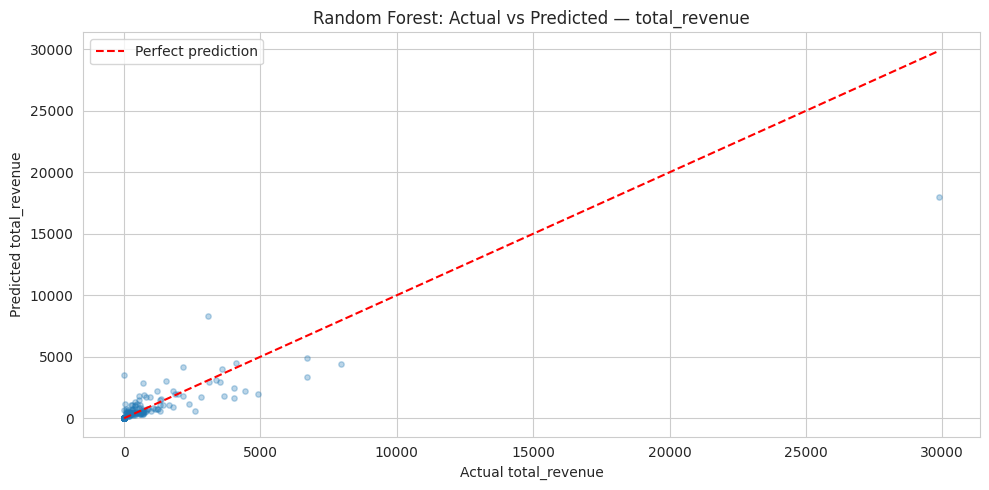

In [154]:
plt.figure()
plt.scatter(y_test, rf_preds, alpha=0.3, s=15)
lims = [0, max(y_test.max(), rf_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual total_revenue")
plt.ylabel("Predicted total_revenue")
plt.title("Random Forest: Actual vs Predicted — total_revenue")
plt.legend()
plt.tight_layout()
plt.show()

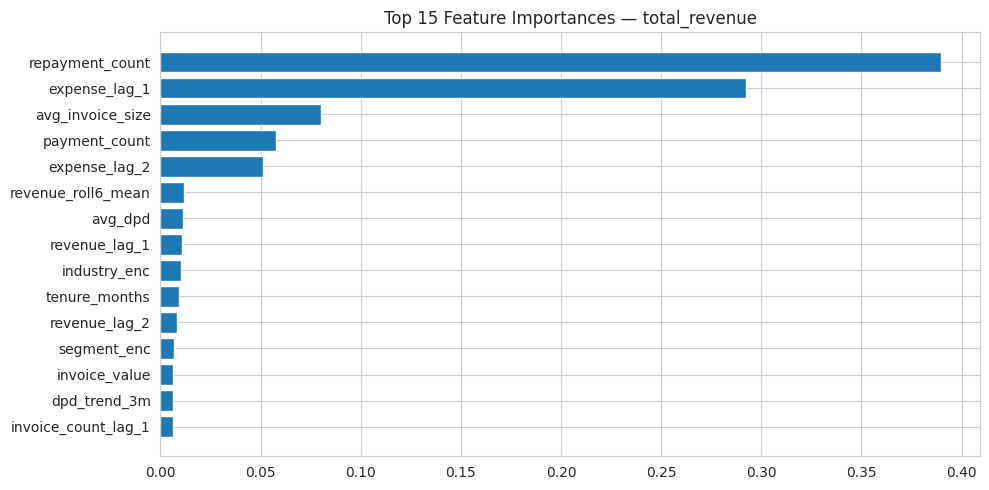

In [155]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top15 = importances.head(15).sort_values()
top15_labels = [str(v) for v in top15.index]
plt.figure()
plt.barh(top15_labels, top15.values)
plt.title("Top 15 Feature Importances — total_revenue")
plt.tight_layout()
plt.show()

## 13. Repeat for the other targets
Same pattern as above (Random Forest only, to keep this section short) —
copy/paste the block for each remaining target.

In [156]:
target = "discount_income"
y_train = train[target]
y_test = test[target]

model_discount = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                        random_state=RANDOM_STATE, n_jobs=-1)
model_discount.fit(X_train, y_train)
preds_discount = np.clip(model_discount.predict(X_test), a_min=0, a_max=None)

print(f"{target} — R2: {r2_score(y_test, preds_discount):.3f}, MAE: {mean_absolute_error(y_test, preds_discount):,.0f}")

discount_income — R2: 0.725, MAE: 121


In [157]:
target = "fee_income"
y_train = train[target]
y_test = test[target]

model_fee = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)
model_fee.fit(X_train, y_train)
preds_fee = np.clip(model_fee.predict(X_test), a_min=0, a_max=None)

print(f"{target} — R2: {r2_score(y_test, preds_fee):.3f}, MAE: {mean_absolute_error(y_test, preds_fee):,.0f}")

fee_income — R2: 0.631, MAE: 151


In [158]:
target = "total_expense"
y_train = train[target]
y_test = test[target]

model_expense = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1)
model_expense.fit(X_train, y_train)
preds_expense = np.clip(model_expense.predict(X_test), a_min=0, a_max=None)

print(f"{target} — R2: {r2_score(y_test, preds_expense):.3f}, MAE: {mean_absolute_error(y_test, preds_expense):,.0f}")

total_expense — R2: 0.988, MAE: 29


## 14. Time Series Forecasting (ARIMA, SARIMA, SARIMAX, Prophet)

Everything above treats each customer-month as an independent row with
features (a "cross-sectional" approach). Time series models instead treat
revenue as a single sequence over time, and use the sequence's own past
values/patterns to forecast forward.

**Granularity choice:** at the *individual customer* level, most customers
here only have revenue in a handful of months (discounting/fee-generating
activity is not a monthly occurrence for every customer), so a single
customer's series is mostly zeros — not a meaningful series to model.
Time series forecasting is just as commonly done at an aggregated level
(e.g. "forecast next month's total portfolio revenue"), which is both a
realistic business question on its own and gives a far more complete,
non-sparse series to demonstrate these models on. That's the approach
used below: total revenue across all customers, per month.

In [159]:
# Portfolio-level monthly series (sum of total_revenue across all customers)
portfolio_revenue = panel_full.groupby("month")["total_revenue"].sum()
portfolio_revenue = portfolio_revenue.asfreq("MS")  # MS = Month Start; one evenly-spaced row per month
portfolio_revenue.head()

,total_revenue
month,
2022-01-01,8203.53
2022-02-01,13920.09
2022-03-01,29425.42
2022-04-01,39768.12
2022-05-01,51501.68


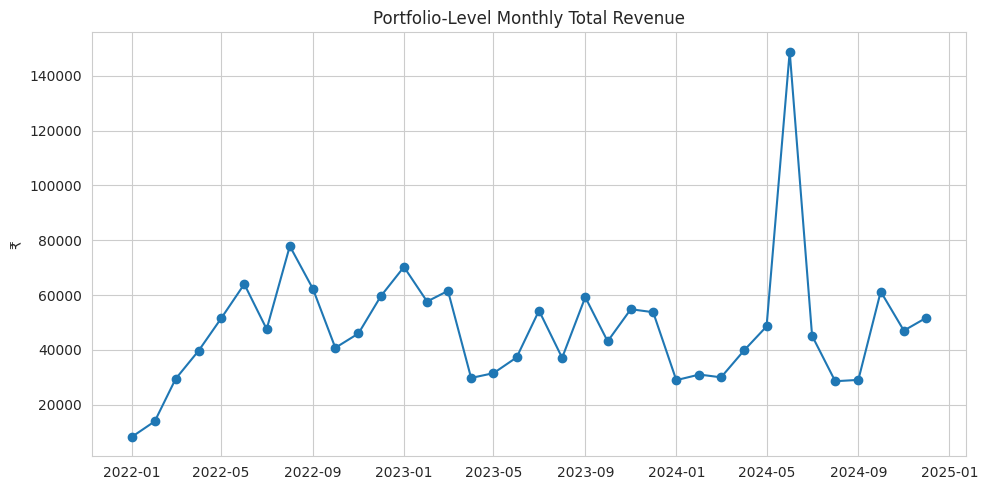

In [160]:
plt.figure()
plt.plot(portfolio_revenue.index, portfolio_revenue.values, marker="o")
plt.title("Portfolio-Level Monthly Total Revenue")
plt.ylabel("₹")
plt.tight_layout()
plt.show()

In [161]:
portfolio_revenue.head()

,total_revenue
month,
2022-01-01,8203.53
2022-02-01,13920.09
2022-03-01,29425.42
2022-04-01,39768.12
2022-05-01,51501.68


In [162]:
# Time-based holdout, same idea as before: last 3 months = test.
# (With only 36 months of history, 3 months keeps a reasonable amount to
# train on. With 5 years / 60 months, as sketched in the original notes, a
# larger holdout like 12-18 months would be more typical.)
ts_train = portfolio_revenue.iloc[:-3]
ts_test = portfolio_revenue.iloc[-3:]
print(f"Train: {ts_train.index.min().date()} to {ts_train.index.max().date()} ({len(ts_train)} months)")
print(f"Test : {ts_test.index.min().date()} to {ts_test.index.max().date()} ({len(ts_test)} months)")

Train: 2022-01-01 to 2024-09-01 (33 months)
Test : 2024-10-01 to 2024-12-01 (3 months)


### 14.1 ADF Test — checking stationarity
ARIMA-family models assume the series is stationary (constant mean/variance
over time, no trend). The Augmented Dickey-Fuller test's null hypothesis
(H0) is "the series is non-stationary." A p-value below 0.05 lets us
reject H0 and treat the series as stationary.

In [163]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts_train)
print(f"ADF statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")
if adf_result[1] < 0.05:
    print("p < 0.05 -> reject H0 -> series is stationary as-is")
else:
    print("p >= 0.05 -> fail to reject H0 -> series is non-stationary -> will difference it (d=1)")

ADF statistic: -4.584
p-value: 0.000
p < 0.05 -> reject H0 -> series is stationary as-is


### 14.2 ACF and PACF plots
Used to visually estimate the AR order (p) and MA order (q). The ACF shows
correlation with each past lag; the PACF shows the same but with the
effect of shorter lags removed. In practice, `auto_arima`-style tools or a
small grid search are used more often than reading these plots by eye —
but the plots are shown here since they're the classical, intuition-building
way to understand *why* an order is chosen.

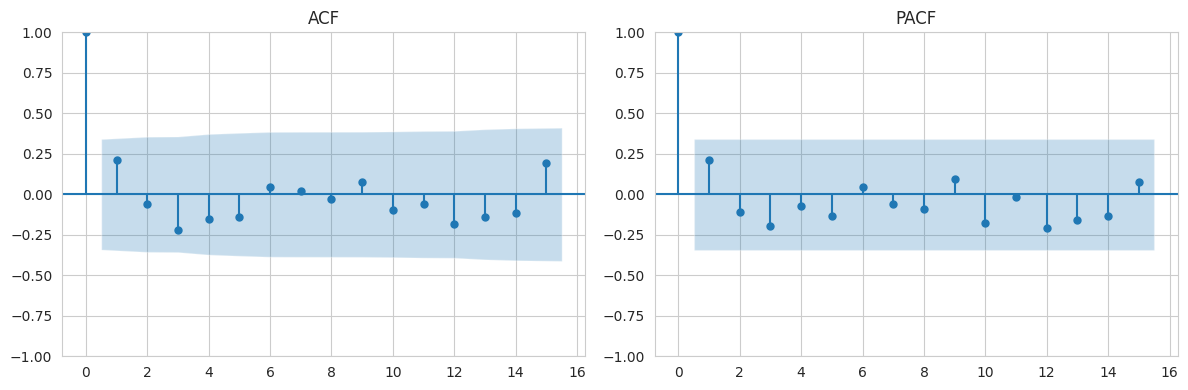

In [164]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_train, ax=axes[0], lags=min(15, len(ts_train) // 2 - 1))
plot_pacf(ts_train, ax=axes[1], lags=min(15, len(ts_train) // 2 - 1))
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

### 14.3 ARIMA(p, d, q)
A simple, commonly-used starting order is (1, 1, 1): 1 autoregressive term,
1 differencing pass (matching the ADF result above), 1 moving-average term.
In a real project you'd tune (p, d, q) using the ACF/PACF plots or a grid
search over AIC — (1,1,1) here is a reasonable, explainable default.

In [165]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(ts_train, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=3)
arima_forecast = arima_forecast.clip(lower=0)  # revenue can't be negative

arima_mae = np.mean(np.abs(ts_test.values - arima_forecast.values))
arima_rmse = np.sqrt(np.mean((ts_test.values - arima_forecast.values) ** 2))
print(f"ARIMA(1,1,1) — MAE: {arima_mae:,.0f}, RMSE: {arima_rmse:,.0f}")

ARIMA(1,1,1) — MAE: 10,017, RMSE: 12,709


### 14.4 SARIMA — Seasonal ARIMA
Adds a seasonal component (P, D, Q, m). BFSI revenue tends to spike around
March (Indian fiscal year-end), so m=12 (yearly seasonality on monthly
data) is the natural choice. Note: with only 33 training months here,
there's barely two seasonal cycles to learn from — real seasonal modeling
benefits from several years of history, as sketched in the original notes.

In [166]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(ts_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=3)
sarima_forecast = sarima_forecast.clip(lower=0)

sarima_mae = np.mean(np.abs(ts_test.values - sarima_forecast.values))
sarima_rmse = np.sqrt(np.mean((ts_test.values - sarima_forecast.values) ** 2))
print(f"SARIMA(1,1,1)(1,1,1,12) — MAE: {sarima_mae:,.0f}, RMSE: {sarima_rmse:,.0f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA(1,1,1)(1,1,1,12) — MAE: 5,770, RMSE: 7,921


```markdown
Let's visualize the SARIMA forecast against the actual values.
```

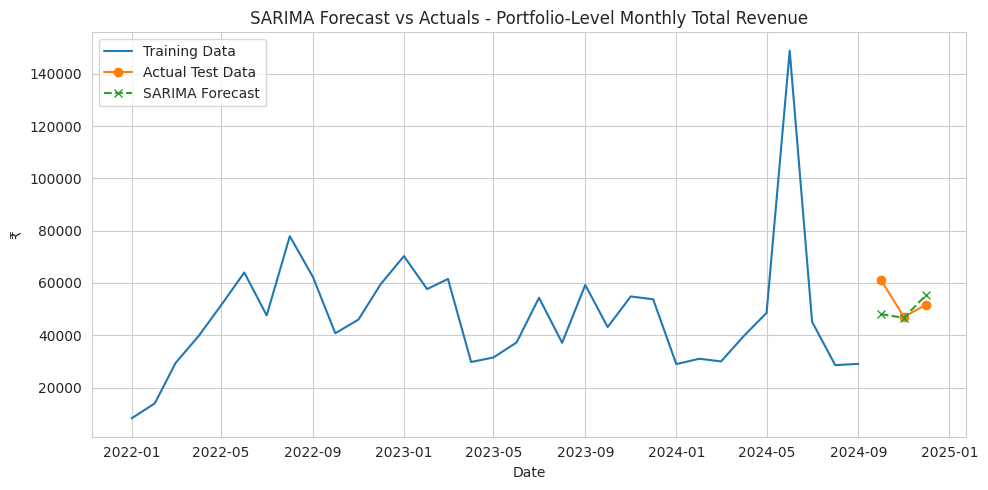

In [167]:
plt.figure(figsize=(10, 5))
plt.plot(ts_train.index, ts_train.values, label='Training Data')
plt.plot(ts_test.index, ts_test.values, label='Actual Test Data', marker='o')
plt.plot(sarima_forecast.index, sarima_forecast.values, label='SARIMA Forecast', linestyle='--', marker='x')
plt.title('SARIMA Forecast vs Actuals - Portfolio-Level Monthly Total Revenue')
plt.xlabel('Date')
plt.ylabel('₹')
plt.legend()
plt.tight_layout()
plt.show()

In [168]:
portfolio_invoice_count = panel_full.groupby("month")["invoice_count"].sum().asfreq("MS")
exog_train = portfolio_invoice_count.iloc[:-3]
exog_test = portfolio_invoice_count.iloc[-3:]

sarimax_model = SARIMAX(ts_train, exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                         enforce_stationarity=False, enforce_invertibility=False)
sarimax_fit = sarimax_model.fit(disp=False)
sarimax_forecast = sarimax_fit.forecast(steps=3, exog=exog_test)
sarimax_forecast = sarimax_forecast.clip(lower=0)

sarimax_mae = np.mean(np.abs(ts_test.values - sarimax_forecast.values))
sarimax_rmse = np.sqrt(np.mean((ts_test.values - sarimax_forecast.values) ** 2))
print(f"SARIMAX (+invoice_count) — MAE: {sarimax_mae:,.0f}, RMSE: {sarimax_rmse:,.0f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMAX (+invoice_count) — MAE: 8,104, RMSE: 10,572


### 14.6 Prophet
A different library entirely (originally built by Meta), designed to work
well with minimal manual tuning of orders. Prophet expects a specific
input shape: a `ds` (date) column and a `y` (value) column.

In [169]:
from prophet import Prophet

prophet_train_df = pd.DataFrame({"ds": ts_train.index, "y": ts_train.values})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train_df)

future_dates = prophet_model.make_future_dataframe(periods=3, freq="MS")
prophet_forecast_full = prophet_model.predict(future_dates)

# Keep only the forecasted (test-period) rows
prophet_forecast = prophet_forecast_full.set_index("ds")["yhat"].iloc[-3:]
prophet_forecast = prophet_forecast.clip(lower=0)

prophet_mae = np.mean(np.abs(ts_test.values - prophet_forecast.values))
prophet_rmse = np.sqrt(np.mean((ts_test.values - prophet_forecast.values) ** 2))
print(f"Prophet — MAE: {prophet_mae:,.0f}, RMSE: {prophet_rmse:,.0f}")

Prophet — MAE: 32,475, RMSE: 39,968


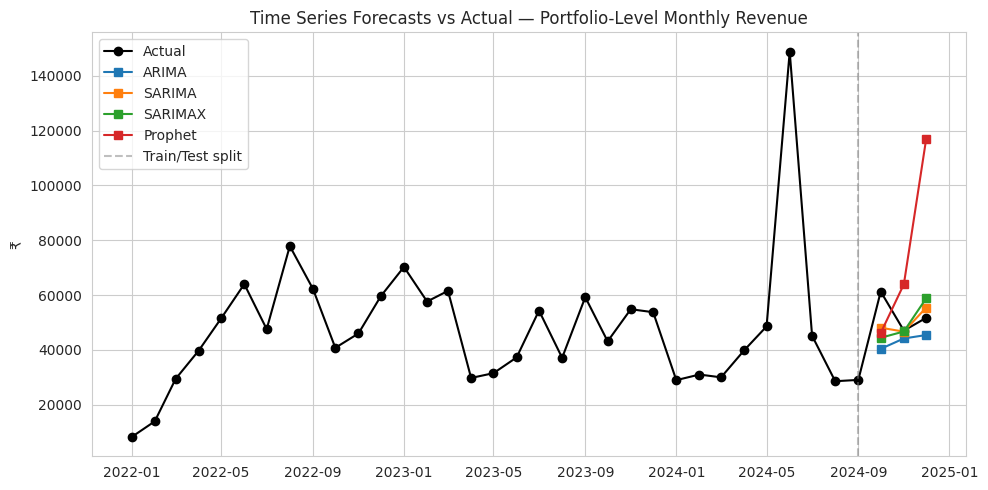

In [170]:
plt.figure()
plt.plot(portfolio_revenue.index, portfolio_revenue.values, marker="o", label="Actual", color="black")
plt.plot(ts_test.index, arima_forecast.values, marker="s", label="ARIMA")
plt.plot(ts_test.index, sarima_forecast.values, marker="s", label="SARIMA")
plt.plot(ts_test.index, sarimax_forecast.values, marker="s", label="SARIMAX")
plt.plot(ts_test.index, prophet_forecast.values, marker="s", label="Prophet")
plt.axvline(ts_train.index.max(), color="grey", linestyle="--", alpha=0.5, label="Train/Test split")
plt.title("Time Series Forecasts vs Actual — Portfolio-Level Monthly Revenue")
plt.ylabel("₹")
plt.legend()
plt.tight_layout()
plt.show()

In [171]:
comparison = pd.DataFrame({
    "Model": ["ARIMA(1,1,1)", "SARIMA(1,1,1)(1,1,1,12)", "SARIMAX (+invoice_count)", "Prophet"],
    "MAE": [arima_mae, sarima_mae, sarimax_mae, prophet_mae],
    "RMSE": [arima_rmse, sarima_rmse, sarimax_rmse, prophet_rmse]
})
comparison

,Model,MAE,RMSE
0,"ARIMA(1,1,1)",10016.589845,12708.566826
1,"SARIMA(1,1,1)(1,1,1,12)",5770.031651,7920.669496
2,SARIMAX (+invoice_count),8103.731880,10572.357227
3,Prophet,32475.166610,39968.236693


In [172]:
comparison = pd.DataFrame({
    "Model": ["ARIMA(1,1,1)", "SARIMA(1,1,1)(1,1,1,12)", "SARIMAX (+invoice_count)", "Prophet"],
    "MAE": [arima_mae, sarima_mae, sarimax_mae, prophet_mae],
    "RMSE": [arima_rmse, sarima_rmse, sarimax_rmse, prophet_rmse],
})
comparison

,Model,MAE,RMSE
0,"ARIMA(1,1,1)",10016.589845,12708.566826
1,"SARIMA(1,1,1)(1,1,1,12)",5770.031651,7920.669496
2,SARIMAX (+invoice_count),8103.731880,10572.357227
3,Prophet,32475.166610,39968.236693


In [173]:
X_full = panel[feature_cols].fillna(train[feature_cols].median())

forecast_table = panel[["customer_id", "month"]].copy()
forecast_table["total_revenue_actual"] = panel["total_revenue"]
forecast_table["total_revenue_forecast"] = np.clip(rf_model.predict(X_full), a_min=0, a_max=None)
forecast_table["discount_income_forecast"] = np.clip(model_discount.predict(X_full), a_min=0, a_max=None)
forecast_table["fee_income_forecast"] = np.clip(model_fee.predict(X_full), a_min=0, a_max=None)
forecast_table["total_expense_forecast"] = np.clip(model_expense.predict(X_full), a_min=0, a_max=None)
forecast_table["profitability_forecast"] = forecast_table["total_revenue_forecast"] - forecast_table["total_expense_forecast"]

forecast_table.head()

,customer_id,month,total_revenue_actual,total_revenue_forecast,discount_income_forecast,fee_income_forecast,total_expense_forecast,profitability_forecast
1,CUST00001,2022-02-01,2272.46,1780.45937,1715.38277,304.511863,150.000000,1630.459370
2,CUST00001,2022-03-01,0.00,0.00000,0.00000,0.000000,0.349899,-0.349899
3,CUST00001,2022-04-01,0.00,0.00000,0.00000,0.000000,0.000000,0.000000
4,CUST00001,2022-05-01,0.00,0.00000,0.00000,0.000000,0.000000,0.000000
5,CUST00001,2022-06-01,0.00,0.00000,0.00000,0.000000,0.000000,0.000000
